<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/adult.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [34]:
null_col = df.isnull().sum()/len(df)*100

In [35]:
null_col

,0
age,0.0
workclass,0.0
fnlwgt,0.0
education,0.0
educational-num,0.0
marital-status,0.0
occupation,0.0
relationship,0.0
race,0.0
gender,0.0


In [36]:
(df == "?").sum()/len(df)*100

,0
age,0.000000
workclass,5.730724
fnlwgt,0.000000
education,0.000000
educational-num,0.000000
marital-status,0.000000
occupation,5.751198
relationship,0.000000
race,0.000000
gender,0.000000


In [37]:
df['workclass'].value_counts()

,count
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
?,2799
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10


In [49]:
mode = df['occupation'].mode()[0]
df['occupation'] = df['occupation'].replace('?', mode)

In [39]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [46]:
df.drop(['educational-num','fnlwgt'],axis=1,inplace=True)

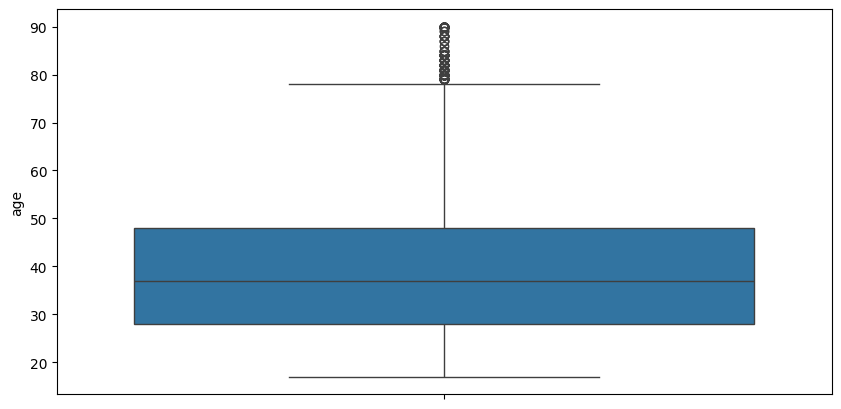

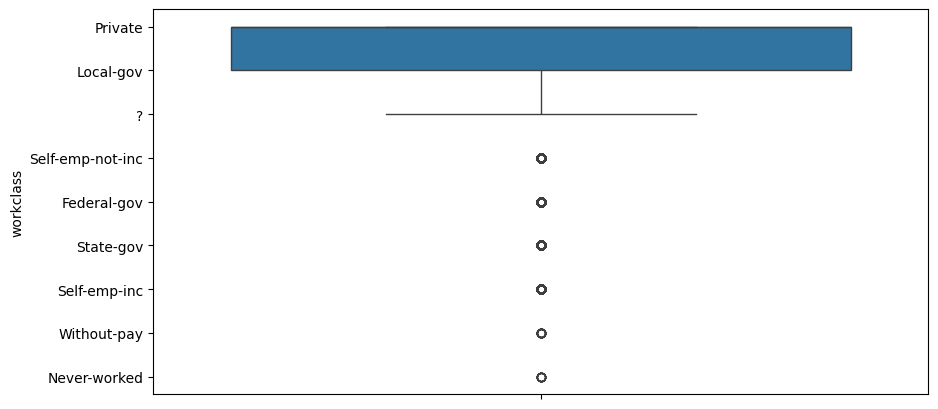

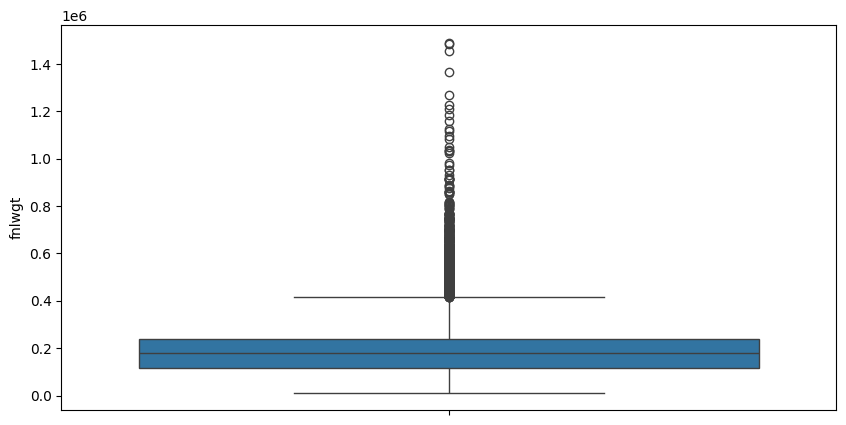

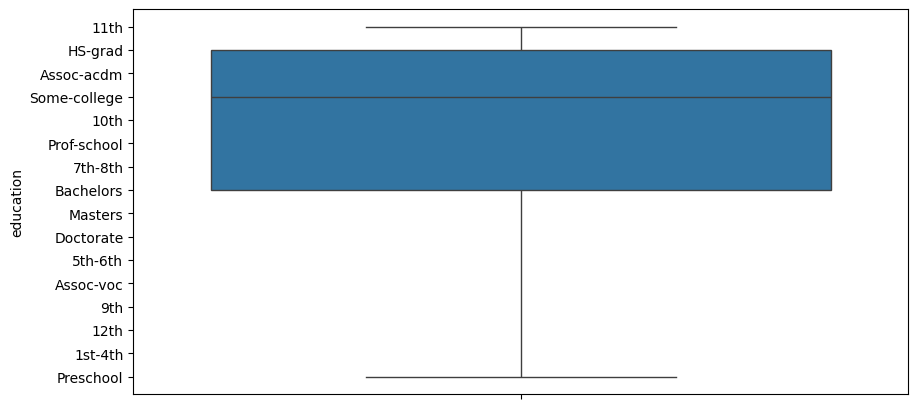

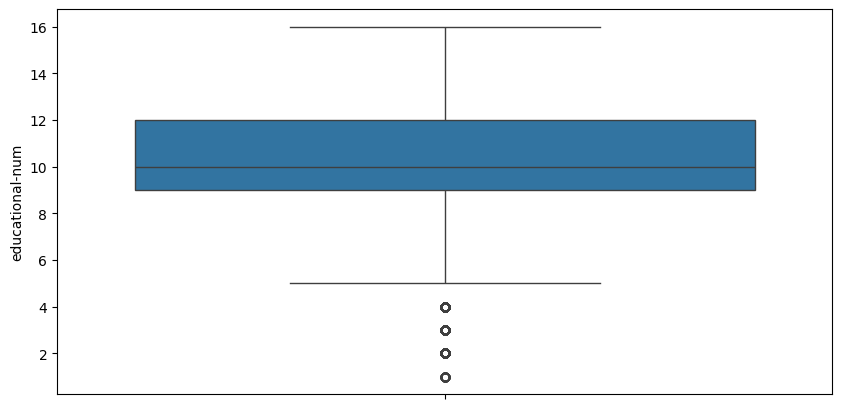

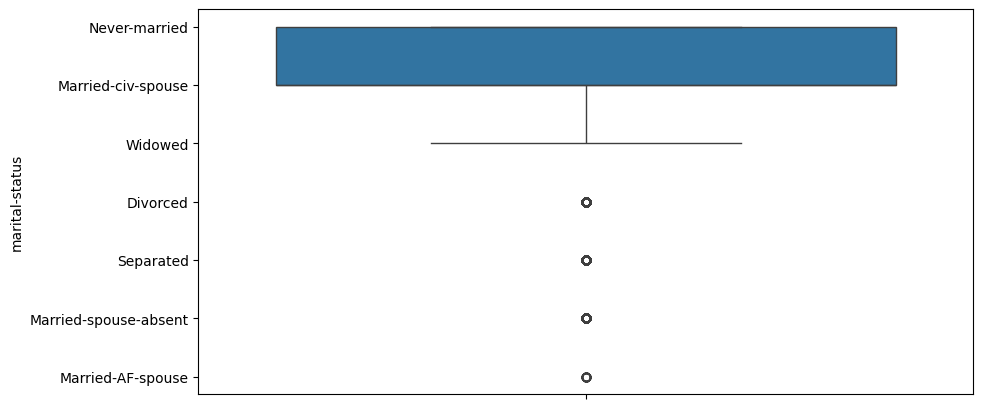

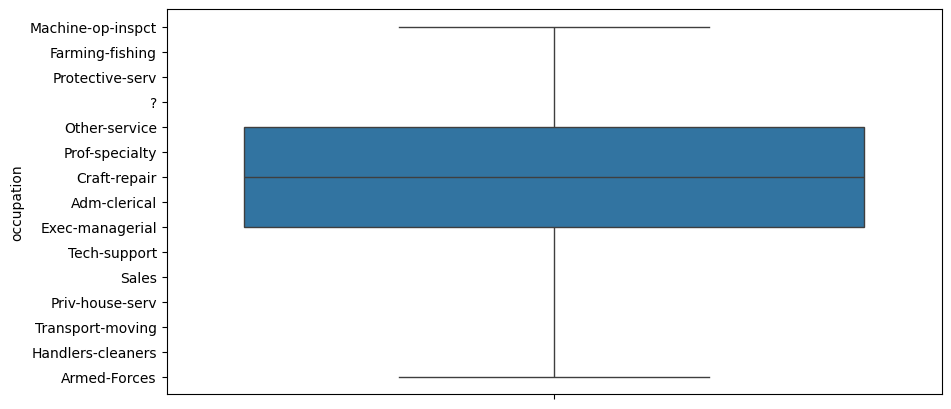

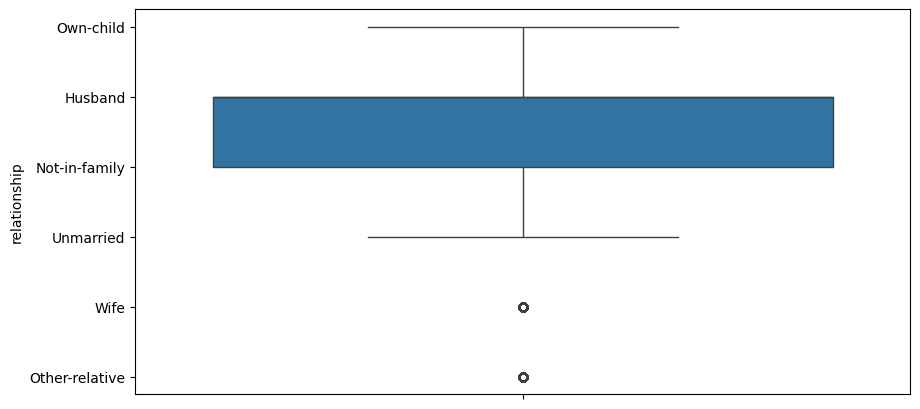

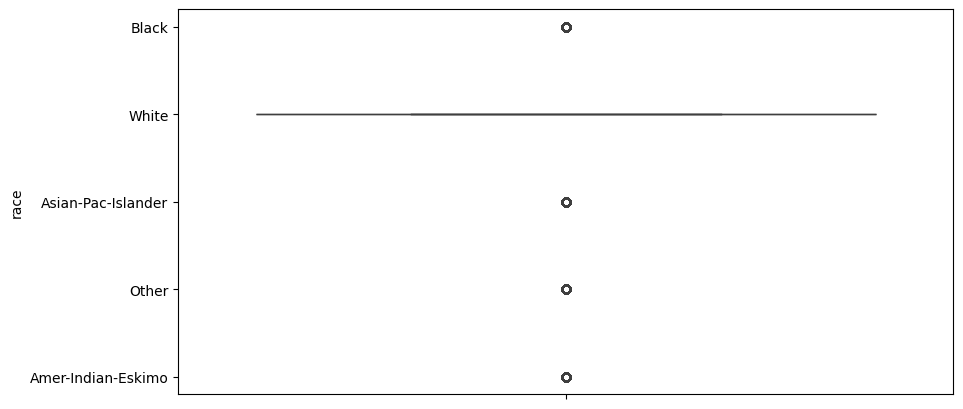

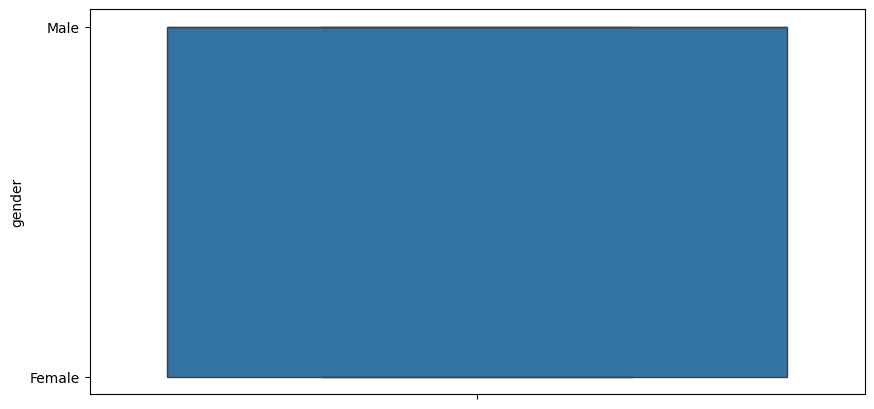

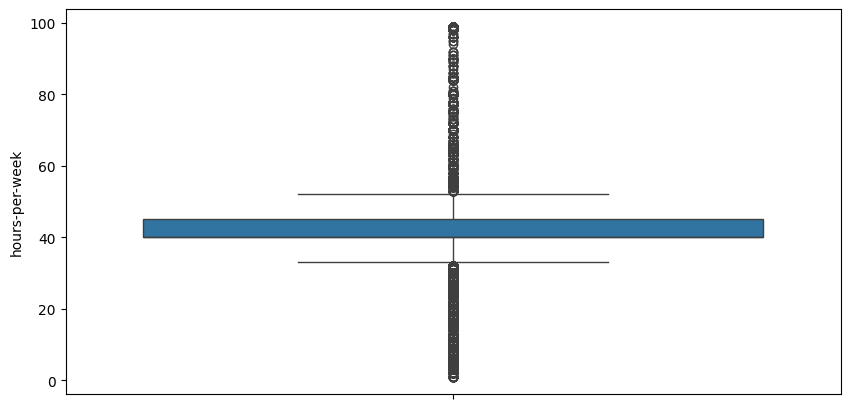

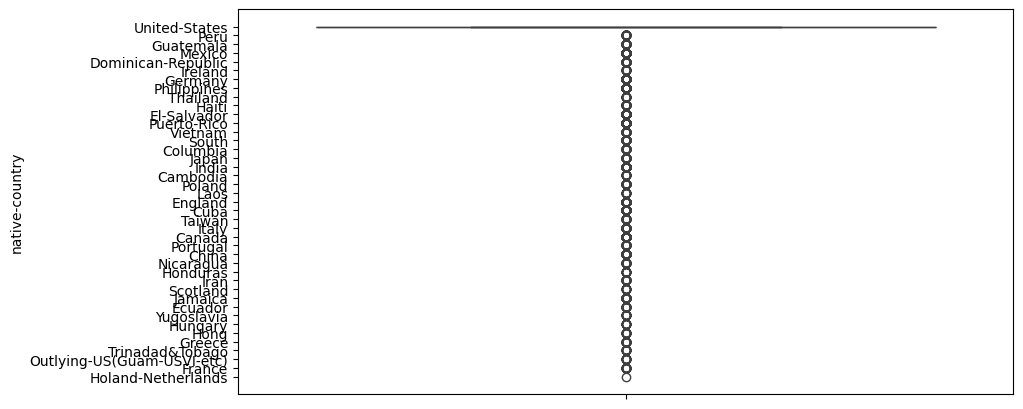

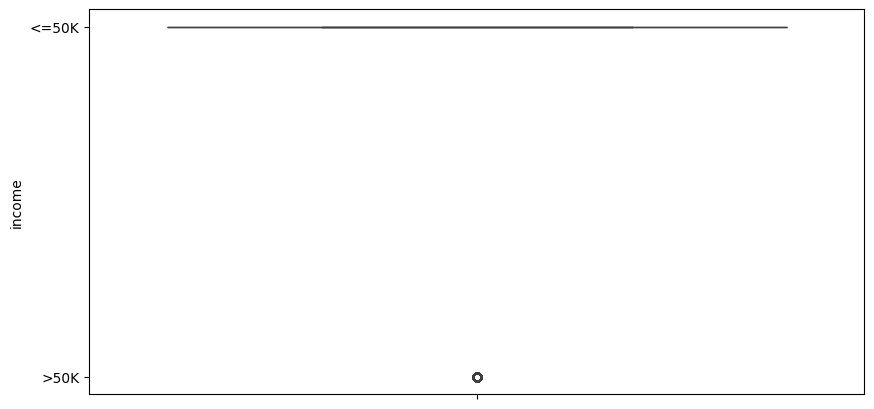

In [41]:
for col in df.columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.show()

In [42]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['age'] = df['age'].clip(lower, upper)

In [43]:
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['hours-per-week'] = df['hours-per-week'].clip(lower, upper)

In [50]:
df

,age,workclass,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,40.0,US,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,50.0,US,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,40.0,US,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40.0,US,>50K
4,18,Private,Some-college,Never-married,Prof-specialty,Own-child,White,Female,32.5,US,<=50K
...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,38.0,US,<=50K
48838,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40.0,US,>50K
48839,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,40.0,US,<=50K
48840,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,32.5,US,<=50K


In [45]:
df['native-country'] = df['native-country'].apply(lambda x : 'US' if x == 'United-States' else 'NON-US')

In [52]:
y = df['income']
x = df.drop('income',axis=1)

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
num_col = x.select_dtypes(include=np.number)
cat_col = x.select_dtypes(exclude=np.number)

In [71]:
num_col

,age,hours-per-week
0,25,40.0
1,38,50.0
2,28,40.0
3,44,40.0
4,18,32.5
...,...,...
48837,27,38.0
48838,40,40.0
48839,58,40.0
48840,22,32.5


In [72]:
cat_col

,workclass,education,marital-status,occupation,relationship,race,gender,native-country
0,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,US
1,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,US
2,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,US
3,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,US
4,Private,Some-college,Never-married,Prof-specialty,Own-child,White,Female,US
...,...,...,...,...,...,...,...,...
48837,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,US
48838,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,US
48839,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,US
48840,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,US


In [73]:
cat_col = pd.get_dummies(cat_col)

In [80]:
cat=cat_col.astype(int)

In [75]:
colu = num_col.columns

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_col = scaler.fit_transform(num_col)

In [77]:
num_col = pd.DataFrame(num_col,columns=colu)

In [81]:
finaldf = pd.concat([num_col,cat],axis=1)

In [82]:
finaldf

,age,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,...,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,gender_Female,gender_Male,native-country_NON-US,native-country_US
0,-0.999145,-0.192863,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
1,-0.045382,1.424021,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
2,-0.779046,-0.192863,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
3,0.394816,-0.192863,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
4,-1.512710,-1.405526,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,-0.852412,-0.516240,0,0,0,1,0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
48838,0.101351,-0.192863,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
48839,1.421946,-0.192863,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,1
48840,-1.219244,-1.405526,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1


In [83]:
from sklearn.neighbors import KNeighborsClassifier  # Importing K Neighbors Classifier
from sklearn.metrics import confusion_matrix, classification_report

In [98]:
x_train_processed = finaldf.loc[x_train.index]
x_test_processed = finaldf.loc[x_test.index]

# Initialize KNN with k=5
kNN = KNeighborsClassifier(n_neighbors=10)

# Train the model
kNN.fit(x_train_processed, y_train)

# Make predictions on the test set
y_pred = kNN.predict(x_test_processed)

# Generate confusion matrix and classification report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[6909  570]
 [1014 1276]]

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      7479
        >50K       0.69      0.56      0.62      2290

    accuracy                           0.84      9769
   macro avg       0.78      0.74      0.76      9769
weighted avg       0.83      0.84      0.83      9769



In [96]:
train_accuracy = []  # List to store training accuracy scores for different values of K
test_accuracy = []
for i in range(1, 20):
    # Initialize KNN classifier with current value of K
    kn = KNeighborsClassifier(n_neighbors=i)
    kn.fit(x_train_processed, y_train)
    tr = kn.score(x_train_processed, y_train)  # Training accuracy
    te = kn.score(x_test_processed, y_test)

    train_accuracy.append(tr)
    test_accuracy.append(te)


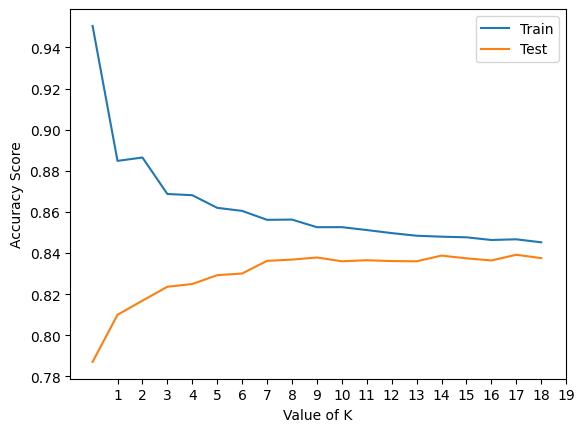

In [97]:
plt.plot(train_accuracy, label="Train")  # Plotting training accuracy scores
plt.plot(test_accuracy, label="Test")    # Plotting testing accuracy scores
plt.legend()                             # Displaying legend
plt.xlabel("Value of K")                  # Labeling x-axis
plt.ylabel("Accuracy Score")             # Labeling y-axis
plt.xticks(np.arange(1, 20))             # Setting x-axis ticks
plt.show()